# Chapter 4 — Estimating Expected Returns

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion.

Three chapters spent on risk; zero on return. This chapter fills the gap. The reader leaves with two related findings: (1) historical mean as an estimator of true expected return is **brutally noisy** at any reasonable sample size, and (2) **shrinkage toward a prior** is the standard remedy. Both findings honestly inform Chapter 5's Sharpe ratio.

## What we mean by "expected return"

When this chapter says "expected return," it doesn't mean a single thing. There are at least four flavors that don't reduce to each other:

1. **Realized return** — what *actually happened* over some past window. Not an expectation at all — it's the **data** we use as input.
2. **Long-run / unconditional expected return** — "what's the asset's true average return over a long period?" A single number characterizing the data-generating process. **(This chapter, §2 + §3.)**
3. **Conditional / forecast expected return** — "given what we know *right now*, what's *next* period's expected return?" A prediction that varies day-to-day. *Deferred — Ch11–12 (strategy edge).*
4. **Equilibrium / required return** — "given the asset's risk and factor exposures, what *should* its expected return be?" *Deferred — Ch8 (CAPM, Fama–French).*

When the rest of this chapter says "expected return," read it as the **long-run unconditional flavor**. Same disclaimer pattern Ch2 and Ch3 used.

## 1. Setup and data refresh

Same library stack and same 8-ticker basket as Chapter 3. We re-pull the data and compute log returns; the only new operation in this chapter is the sample mean and its standard error.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"yf      {yf.__version__}")

numpy   2.4.4
pandas  3.0.2
yf      1.3.0


In [35]:
tickers = ["SPY", "TLT", "GLD", "XLK", "XLF", "XLE", "XLV", "XLU"]
data = yf.download(tickers, period="20y", progress=False)
prices = data["Close"][tickers]
log_returns = np.log(prices / prices.shift(1)).dropna()

n_obs = len(log_returns)
print(f"shape: {log_returns.shape}")
print(f"date range: {log_returns.index.min().date()} to {log_returns.index.max().date()}")
print(f"observations per asset: {n_obs:,}")

shape: (5031, 8)
date range: 2006-05-02 to 2026-04-30
observations per asset: 5,031


### Realized vs expected — keep them straight

The cell below computes the **mean of realized returns** for each asset. That is *not* the same as the asset's *expected* return. Realized return is the data; expected return is the underlying parameter we're trying to estimate. Most of this chapter is about the gap between those two ideas.

In [36]:
daily_mean = log_returns.mean()
ann_mean = daily_mean * 252  # annualize: means add over time, multiply by trading days

summary = pd.DataFrame({
    "daily mean (log)":   daily_mean,
    "annualized mean":    ann_mean,
    "annualized vol":     log_returns.std() * np.sqrt(252),
})
summary

,daily mean (log),annualized mean,annualized vol
Ticker,,,
SPY,0.000413,0.103993,0.194475
TLT,0.000131,0.032929,0.149075
GLD,0.000372,0.093772,0.182762
XLK,0.000586,0.147693,0.229274
XLF,0.000209,0.052547,0.298291
XLE,0.000260,0.065496,0.302448
XLV,0.000378,0.095285,0.169975
XLU,0.000357,0.089997,0.188979


## 2. Part I — The naive estimator and its noise

The natural estimator of an asset's expected return is the **sample mean** — just average the realized returns you have.

> *μ̂* = (1/N) Σᵢ *rᵢ*

where:
- *rᵢ* — the realized log return on day *i*. **Units:** decimal fraction per day (e.g., 0.005 means a 0.5% daily return). Daily, not annualized.
- *N* — the number of observations in the sample.
- *μ̂* — the sample-mean estimator. **Units:** same as *rᵢ* (per day) unless explicitly annualized.

> **Foot-gun: annualizing a mean.** To go from daily to annualized, **multiply by 252** (means *add* over independent time periods). This is *different* from the std/vol annualization rule from Ch1, which used **× √252** (variances add; standard deviations scale by √t). Don't conflate them: mean × 252, std × √252, variance × 252.

### 2.2 Standard error of the mean

The sample mean is an *estimator*. Like any estimator, it has its own sampling distribution — different samples of the same population give different *μ̂* values. The width of that sampling distribution is the **standard error**:

> *SE(μ̂)* = *σ* / √N

where:
- *σ* — the standard deviation of the underlying data (same units as the data).
- *N* — sample size.
- *SE(μ̂)* — standard deviation of the sampling distribution of the sample mean. **Units:** same as *μ̂*.

> **Foot-gun: SE shrinks like √N, not N.** Doubling sample size only reduces SE by √2 ≈ 1.41×. Quadrupling N halves SE. This is *aggressively diminishing returns* — and it's why even decades of data leave wide CIs on expected return.

> **Foot-gun: annualizing SE.** Treat SE the same way you treat the mean: **× 252** to annualize (since SE is in the *same units as the mean*, and means scale linearly with time horizon). Do not use √252.

A 95% confidence interval, assuming approximate normality of the sample mean:

> *CI₉₅* = *μ̂* ± 1.96 · *SE(μ̂)*

The 1.96 is the 0.975 quantile of the **standard normal distribution** — the normal distribution with mean 0 and standard deviation 1, written *N(0, 1)*. The 0.975 quantile is the value below which 97.5% of the standard-normal area sits; symmetry of the distribution puts 2.5% above +1.96 and 2.5% below −1.96, summing to a 5% "rejection region" outside the CI.

> **Why does the sample mean's distribution become approximately normal?** The **Central Limit Theorem (CLT)** is a foundational statistics result: when you average enough independent samples from any reasonably-behaved distribution, the *average's* distribution becomes approximately normal regardless of the original distribution's shape. With ~5,000 daily returns, the CLT applies cleanly even though individual returns are fat-tailed (Ch2). It's why a *μ̂* ± 1.96·SE interval is defensible even though the inputs aren't themselves normal.

#### The t-statistic and hypothesis testing — the same idea as the CI, packed into one number

The same calculation can be expressed as a single ratio:

> *t* = *μ̂* / *SE(μ̂)*

where:
- *μ̂* — the sample mean.
- *SE(μ̂)* — its standard error.
- *t* — **t-statistic**: how many standard errors the estimate sits from zero. **Units:** unitless ratio.

"*|t| > 1.96*" and "the 95% CI excludes zero" say *exactly the same thing* — the inequality just rearranges the CI formula. The t-statistic is the convenient single-number form when you're tabulating many estimates side by side or asking a yes/no question of one.

> **Hypothesis test framing.** When a researcher asks "is the true mean statistically distinguishable from zero?", they're running a **null hypothesis test**:
>
> - **H₀ (null hypothesis):** μ = 0 — there's no effect; the asset's true expected return is zero.
> - **H₁ (alternative hypothesis):** μ ≠ 0 — there is an effect.
>
> The test **rejects H₀** at confidence level *c* when |*t*| exceeds the threshold for that level. The thresholds are quantiles of the standard normal:
>
> | Confidence | Threshold | One-sided tail probability |
> | --- | ---: | ---: |
> | 90% | 1.645 | 5% in each tail |
> | 95% | 1.960 | 2.5% in each tail |
> | 99% | 2.576 | 0.5% in each tail |
>
> "Reject H₀ at 95%" means: under the null, you'd see |*t*| this large by chance only 5% of the time, so the data is hard to reconcile with H₀.
>
> **Two-sided vs one-sided.** The thresholds above are for **two-sided** tests — we reject H₀ for either μ > 0 or μ < 0; both directions count. A **one-sided** test only rejects in one pre-specified direction (e.g., "is this strategy's mean *positive*?") and uses a slightly looser threshold (1.645 instead of 1.96 at 95%). All tests in this curriculum are two-sided unless explicitly stated.

Compute SPY's 95% CI from the full 20-year window:

In [37]:
daily_mean_spy = log_returns["SPY"].mean()
daily_std_spy  = log_returns["SPY"].std()
n              = len(log_returns)

se_daily = daily_std_spy / np.sqrt(n)
se_ann   = se_daily * 252                           # multiply by 252 (NOT sqrt-252)

mean_ann   = daily_mean_spy * 252
ci_low_ann = mean_ann - 1.96 * se_ann
ci_hi_ann  = mean_ann + 1.96 * se_ann

print(f"N (observations):                 {n:,}")
print(f"SPY annualized mean:              {mean_ann:.2%}")
print(f"SPY annualized SE of the mean:    {se_ann:.2%}")
print(f"95% CI on annualized mean:        [{ci_low_ann:.2%}, {ci_hi_ann:.2%}]")
print(f"CI width:                         {ci_hi_ann - ci_low_ann:.2%}")

N (observations):                 5,031
SPY annualized mean:              10.40%
SPY annualized SE of the mean:    4.35%
95% CI on annualized mean:        [1.87%, 18.93%]
CI width:                         17.06%


**What does this CI actually claim?** Subtle but important — most casual explanations get this wrong:

1. **It's NOT** "there's a 95% probability the true value is in [1.84%, 18.90%]." Once the data is in and the interval is computed, the true value either is or isn't in there — no probability about it.
2. **The "95%" describes the *procedure*, not this specific interval.** If we ran the same calculation on a thousand different 20-year samples, 95% of the resulting intervals would contain the true value. Our particular interval is one of those thousand; we don't know whether it's one of the 950 that contains the truth or one of the 50 that doesn't.
3. **In conversation, "we're 95% confident the true mean is in this range" is fine.** It communicates the right intuition for any decision-making purpose, even though it's technically the wrong semantics.
4. **A wide CI doesn't mean we were "careless."** It means our best honest procedure can't pin down the true value tighter than this with the data we have. The path forward isn't "be more careful with the data" — it's more data, a different estimator (§3 shrinkage), or outside information.

Useful mental picture: imagine the true expected return is a stake driven into the ground at an unknown spot. Your sample mean tosses a horseshoe; the CI is the ring it forms. You can't see the stake. Your *tossing technique* rings the stake 95% of the time across many tosses. The horseshoe you just threw either rings it or it doesn't — but you trust the technique.

Twenty years of daily SPY data — over 5,000 observations — and the 95% CI on the annualized mean is **roughly 17 percentage points wide** (~1.84% to ~18.90%). To make that range concrete for a reader without a finance background, translate each end:

**Lower bound (~1.84%): "no equity premium."** Compare to **T-bills** — short-term US Treasury debt (maturities from a few weeks to a year), conventionally treated as the closest thing to a "risk-free" rate (the US government has never defaulted on dollar-denominated debt). T-bills averaged **roughly 2% annualized** over the 20-year window — near 0% from 2009–2015 and 2020–2021, then 4–5%+ in 2022–2024. So at the lower CI bound, SPY's true expected return is essentially tied with T-bills, meaning **no equity premium** — you'd have earned the same money in cash with no equity risk.

**Upper bound (~18.90%): "doubles every four years."** Apply the **Rule of 72** — a mental shortcut where doubling time in years ≈ 72 / annualized return %. So 72 / 18.90 ≈ **3.8 years**. At 18.90% annualized, $100k becomes ~$200k in just under four years. Late-1990s tech-boom territory.

**Same data, two opposite worldviews.** "Stocks aren't worth the risk" vs "stocks are an obvious slam dunk." The historical mean alone can't tell you which — and this is *with* twenty years of data. For shorter samples the situation is worse, by exactly √(years).

### 2.3 Subsample stability — same data, different windows

A different angle on the same problem: pick disjoint sub-windows of the same data and compute the sample mean on each. If the long-run mean were a stable property of the asset, the sub-window means would cluster tightly. They don't.

In [38]:
spy = log_returns["SPY"]
window_years = 5

start_year = spy.index.year.min()
end_year   = spy.index.year.max()

rows = []
for y0 in range(start_year, end_year, window_years):
    y1 = y0 + window_years - 1
    window = spy.loc[str(y0):str(y1)]
    if len(window) < 252:  # skip incomplete tail windows
        continue
    rows.append({
        "window":              f"{y0}-{y1}",
        "n days":              len(window),
        "annualized mean":     f"{window.mean() * 252:.2%}",
        "annualized vol":      f"{window.std() * np.sqrt(252):.2%}",
    })

pd.DataFrame(rows)

,window,n days,annualized mean,annualized vol
0,2006-2010,1177,1.34%,25.58%
1,2011-2015,1258,11.73%,15.38%
2,2016-2020,1259,14.07%,18.97%
3,2021-2025,1255,13.45%,17.09%


The annualized mean varies by 5–10 percentage points across disjoint 5-year windows of the same asset.

> **What was the "2008 crisis"?** Formally the **Global Financial Crisis (GFC)** — a global financial collapse triggered by US subprime housing-loan defaults that cascaded through banks, money markets, and credit spreads. SPY drew down ~55% peak-to-trough into March 2009. Realized vol in our 2006–2010 window averaged ~25%, vs ~15–18% for the calmer windows below.
>
> **What was the "2022 selloff"?** The Federal Reserve's most aggressive rate-hike cycle in four decades — pushing the federal-funds rate (the rate banks pay each other for overnight loans, set by the Fed and used as the baseline for nearly all other rates) from ~0% to ~4.5% in nine months — repriced both stocks and bonds simultaneously. SPY drew down ~25% in 2022; long-duration bonds (TLT) drew down ~30%+ in the same window. This appears in the **2021–2025** sub-window.

Some windows include the GFC or the 2022 selloff and look terrible; others are squarely in calm bull markets and look great. **None of them is "wrong"** — they're all valid sample means of real data — but the spread is exactly the noise the standard error formula was telling us about, made visceral.

### 2.4 What this means with $100k

Reading §2.2's CI in dollar terms on a $100k position:

- **Lower end ($1,840/year, ~1.84%).** Essentially tied with T-bills (~2% over the window — see §2.2 for what T-bills are and why they're the natural comparison). The CI is consistent with SPY earning **no equity premium** in expectation. Strict reading: the lower bound is actually slightly *below* the average T-bill rate, so the CI is even consistent with underperforming cash.
- **Upper end ($18,900/year, ~18.90%).** "Doubling every ~3.8 years" via the Rule of 72 (introduced in §2.2). The CI is consistent with SPY being a generational investment.

**Both extremes are statistically consistent with the same 20 years of data.**

Two practical takeaways before we move on:
1. **Don't confuse a point estimate with the truth.** The 10% headline number is the *center* of a wide distribution, not a fact.
2. **The next chapter's Sharpe ratio inherits this uncertainty.** A 0.5 reported Sharpe with 20 years of data has its own large CI; "is this strategy any good?" can't be answered just from the point estimate.

## 3. Part II — Shrinkage: pulling estimates toward a prior

Section 2 showed that *each individual* sample mean is noisy. Counterintuitive fact: **even though the sample mean is *unbiased* for any single asset, you can do better in *aggregate* by deliberately introducing a small bias.** Each estimate gets pulled toward a common prior; in exchange, the total mean-squared error across all assets goes down. This is the **bias-variance tradeoff** — the foundational idea behind a huge swath of statistics and ML.

> **Vocabulary for §3** — a handful of statistics terms get used heavily below; defining them inline so the rest of the section reads cleanly.
>
> - **Bias** — the expected difference between an estimator's output and the true value, *averaged across all possible samples*. Formally: *Bias(μ̂) = E[μ̂] − μ*. An **unbiased** estimator has zero bias on average. The sample mean is unbiased for the population mean: *E[μ̂] = μ*.
> - **Unbiased ≠ accurate.** Any single sample's *μ̂* can still be far from the truth. Unbiasedness is a property of the *estimator* across infinitely many repeated samples, not of any particular estimate from one sample.
> - **Variance of an estimator** — how much *μ̂* wobbles around its average across different samples. Square root = the standard error from §2.2.
> - **Mean-squared error (MSE)** — average squared distance from the estimator's output to the truth, across all possible samples: *MSE(μ̂) = E[(μ̂ − μ)²] = Bias(μ̂)² + Var(μ̂)*. MSE combines both kinds of error in one number; that decomposition is exact.
> - **Bias-variance tradeoff** — accepting a small bias (deliberately pulling the estimate away from the unbiased value) can *reduce* MSE if it shrinks variance by more than it inflates bias². That's the formal statement of "shrinkage trades a little bias for a lot of stability."

> **What's a "prior"?** A **prior** is a default guess for the parameter you're trying to estimate, chosen *before* (or independently of) looking at this particular sample — it's whatever you'd believe in the absence of data. The term comes from Bayesian statistics, where you literally combine a prior with the data to get a "posterior" updated belief; we're using it more loosely here, just to mean the value we shrink toward. Common choices in this chapter: the **cross-sectional mean** (defined below) or **zero** ("in the absence of evidence, assume no return"). The prior doesn't have to be exactly right — it just has to be a reasonable default that, when blended with noisy data, produces a less noisy combined estimate than the data alone.

> **What's "cross-sectional"?** "Cross-sectional" means **across assets at a single point in time** — as opposed to **time-series**, which means *across time for one asset*. If you line up all 8 of our tickers and average their 20-year mean returns, that's a cross-sectional average (one number per asset, then averaged across the 8 assets). If you average SPY's daily returns over 20 years, that's a time-series average. The **cross-sectional mean** in this chapter is the average of the 8 individual annualized means — ~8.47% on our basket — and it's the default prior we shrink toward (intuition: "in the absence of evidence, assume each asset earns the basket average").

### 3.1 Intuition

When you have multiple noisy estimates of related quantities, the *spread between them* is partly real (different true means) and partly noise. Pulling them toward a common point shrinks the noise component without distorting the real-spread component too much. With 8 asset means, this almost always reduces total error vs reporting the 8 raw sample means.

The simplest implementation is a **linear blend** between the raw sample mean and a prior:

> *μ̂*<sub>shrink</sub> = *α · μ̂* + (1 − *α*) · *μ*<sub>prior</sub>

where:
- *μ̂* — the raw sample mean.
- *μ*<sub>prior</sub> — the value we're shrinking toward (typically the cross-sectional mean of all assets, sometimes zero).
- *α* — shrinkage weight. **Units: a fraction in [0, 1]**, NOT a percentage. *α* = 1 means no shrinkage (raw sample mean unchanged); *α* = 0 means total shrinkage (everyone gets the prior).
- *μ̂*<sub>shrink</sub> — the shrinkage-adjusted estimator.

### 3.2 The James-Stein estimator

The linear blend works, but the choice of *α* is up to you. The **James-Stein estimator** picks *α* (effectively) using a formula that provably reduces total MSE for any *K* ≥ 3 assets — a remarkable result from Charles Stein in 1956. The positive-part version:

> *μ̂*<sub>JS,i</sub> = *μ*<sub>prior</sub> + max(0, 1 − (*K* − 2) · *v* / *D*) · (*μ̂*<sub>i</sub> − *μ*<sub>prior</sub>)

where:
- *K* — the number of assets being shrunk together.
- *v* — proxy for the variance of each estimate (we use the average of *σ²/N* across assets).
- *D* — squared distance from each raw estimate to the prior, summed across assets: Σᵢ(*μ̂*<sub>i</sub> − *μ*<sub>prior</sub>)².
- "max(0, …)" — the **positive-part correction**: if the formula would produce a negative shrinkage factor, clamp to 0. This prevents over-shrinking past the prior.

> **Foot-gun: the inputs must use the same time scale.** If your *μ̂* and *σ²* are daily, *N* is the number of days. If you've annualized, *N* needs to be in years. Don't mix.

<details>
<summary><b>The math, if you want it: why James-Stein dominates the sample mean</b></summary>

Stein (1956) proved that for *K* ≥ 3 normal means with known equal variances, the sample-mean vector is **inadmissible** under squared-error loss — there exists an estimator that strictly dominates it (lower MSE for *every* possible true-mean vector). James and Stein (1961) gave the explicit form. The key idea: each individual coordinate is unbiased, but the *vector* of estimates has total error that can always be reduced by shrinking toward a point.

The formula minimizes an unbiased estimate of the total MSE. The shrinkage factor `1 − (K − 2)v/D` increases (less shrinkage) when the raw estimates are far from the prior (high *D*) and decreases (more shrinkage) when they're close. The positive-part version replaces negative factors with 0, which strictly improves performance further (Baranchik 1964).

For *K* = 1 or 2, James-Stein doesn't dominate — the sample mean is admissible. The 2-asset case is exactly when shrinkage stops being a free lunch.

</details>

In [39]:
def james_stein_shrink(means, vols, n_obs, prior=None):
    """Apply James-Stein (positive-part) shrinkage to a vector of asset means."""
    means = np.asarray(means, dtype=float)
    vols = np.asarray(vols, dtype=float)
    K = len(means)
    if K < 3:
        return means.copy()  # JS only dominates for K >= 3
    if prior is None:
        prior = means.mean()
    v = (vols ** 2).mean() / n_obs           # avg variance of each estimate
    D = ((means - prior) ** 2).sum()         # sum of squared deviations from prior
    if D == 0:
        return means.copy()
    factor = 1 - (K - 2) * v / D
    factor = max(0.0, factor)                # positive-part
    return prior + factor * (means - prior)


daily_means = log_returns.mean().values
daily_vols  = log_returns.std().values

js_daily = james_stein_shrink(daily_means, daily_vols, n_obs)

shrink = pd.DataFrame({
    "raw mean (annualized)":   daily_means * 252,
    "JS shrunk (annualized)":  js_daily    * 252,
    "shift":                   (js_daily - daily_means) * 252,
}, index=tickers)

cross_sectional_prior = daily_means.mean() * 252
print(f"Prior (cross-sectional mean, annualized): {cross_sectional_prior:.2%}")
print()
shrink

Prior (cross-sectional mean, annualized): 8.52%



,raw mean (annualized),JS shrunk (annualized),shift
SPY,0.103993,0.085214,-0.018779
TLT,0.032929,0.085214,0.052285
GLD,0.093772,0.085214,-0.008558
XLK,0.147693,0.085214,-0.062479
XLF,0.052547,0.085214,0.032667
XLE,0.065496,0.085214,0.019718
XLV,0.095285,0.085214,-0.010071
XLU,0.089997,0.085214,-0.004783


### 3.4 Visualizing the shrinkage

Bar chart: raw sample means vs JS-shrunk estimates. The dashed horizontal line is the prior (cross-sectional mean).

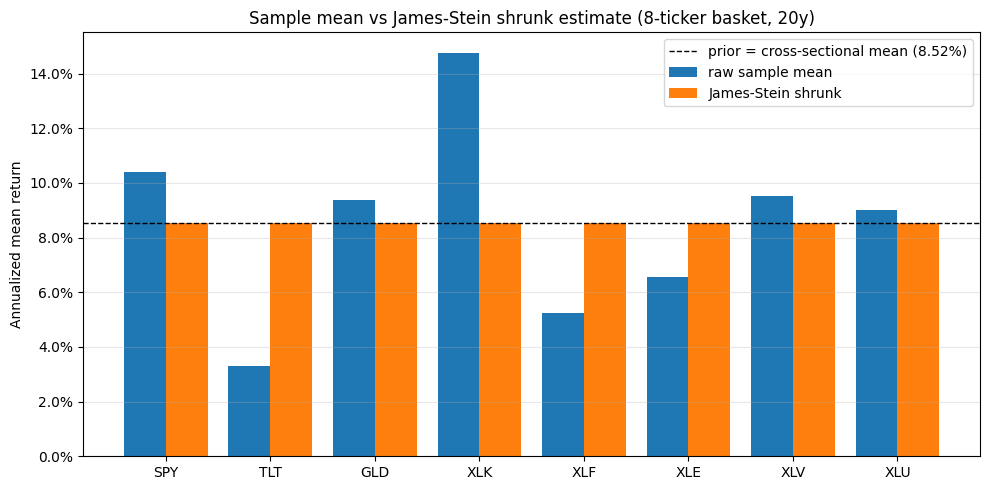

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tickers))
width = 0.4

ax.bar(x - width/2, shrink["raw mean (annualized)"],  width, label="raw sample mean", color="tab:blue")
ax.bar(x + width/2, shrink["JS shrunk (annualized)"], width, label="James-Stein shrunk", color="tab:orange")
ax.axhline(cross_sectional_prior, color="black", ls="--", lw=1,
           label=f"prior = cross-sectional mean ({cross_sectional_prior:.2%})")

ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_ylabel("Annualized mean return")
ax.set_title("Sample mean vs James-Stein shrunk estimate (8-ticker basket, 20y)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
plt.tight_layout()
plt.show()

Look at the "JS shrunk" column: **every asset got pulled all the way to the prior** (8.50% annualized). What's going on?

The JS shrinkage factor *clamped to zero* through the positive-part correction. The formula's way of saying it: **the dispersion you see across these 8 sample means is statistically indistinguishable from pure noise**, given how wide each individual SE is.

Recall §2.2 — SPY's annualized mean alone has a 95% CI of ~17 percentage points. The spread between XLK at 14.7% and TLT at 3.3% (~11 percentage points) doesn't survive contact with that noise floor. Our intuition says these are very different assets; JS is saying *20 years of data isn't enough to confirm that intuition statistically*.

That's a sobering result, but a real one. Two important follow-ups:

1. **Partial shrinkage happens when assets are more separable.** If the raw means were spread far enough apart relative to each estimator's noise (or if we had much more data), the factor wouldn't clamp to zero and we'd see partial movement instead of total. Exercise 3 demonstrates partial shrinkage by changing the prior to zero (which makes *D* much larger relative to *v*).
2. **Total shrinkage is still useful in practice.** Even when JS collapses everything to the prior, that's a legitimate input to portfolio optimization — and in fact, "use the cross-sectional mean for everyone" produces *much* more stable optimal portfolios than naive sample means do. Chapter 6 will demonstrate this directly.

The lesson isn't "JS is broken on financial data." The lesson is: **the historical sample-mean spreads we casually treat as informative often aren't, once we honestly account for noise.**

### 3.5 What this means for portfolio construction

> **Vocabulary heads-up — terms used below before later chapters formalize them.**
> - **Mean-variance optimization (MVO)** — the textbook portfolio-construction method that picks portfolio weights to maximize expected return for a given risk level (or equivalently, minimize risk for a given expected return). Originally Markowitz 1952. Inputs: a vector of expected returns (one per asset) and a covariance matrix (asset-pair correlations × vols). Output: an "efficient" set of weights for each chosen risk level. **Chapter 6** runs MVO end-to-end.
> - **Efficient frontier** — the curve traced out by MVO as you sweep the target risk level from low to high. Each point on the curve is the highest-expected-return portfolio achievable at that level of risk.
> - **Sharpe ratio** — formally introduced in **Chapter 5**; for now, just read it as "expected return per unit of volatility." MVO objectives are mathematically very close to "maximize Sharpe."

**Practitioner-grade fact:** essentially all production mean-variance optimization uses *shrunk* expected-return estimates, not raw sample means. The reason: MVO objectives are *very* sensitive to the input expected returns, and naive sample means produce wildly unstable optimal weights — small changes in the data move the "optimal" portfolio dramatically.

Our §3.4 result reinforces this strongly. JS told us our 8 raw sample means are *statistically indistinguishable* from a common 8.5% mean. A portfolio optimizer fed naive sample means would treat XLK (14.7%) as a far better bet than TLT (3.3%) — and would over-allocate to XLK accordingly. JS-shrunk inputs say "you don't actually have evidence to support that allocation"; the resulting portfolio is more equal-weighted and far more stable.

We'll see this directly in Chapter 6 when we compute efficient frontiers using both raw and shrunk inputs. For now, the takeaway: **trust shrunk estimates further than raw means, especially when the raw means feel surprisingly informative.**

## 4. Part III — Forecasting (the conditional flavor) — preview only

Sections 2 and 3 dealt with *one* flavor of expected return: the long-run unconditional mean. The other interesting flavor is the **conditional** one: instead of asking *"what's the asset's average return over a long period?"* (one number), ask *"what's its expected return *next period* given *what we know now*?"* (a number per asset *per time*).

This is a different problem with different methods, different success criteria, and its own chapters in this curriculum.

### 4.2 Two routes to forecasting

Both are explicitly deferred to later chapters:

- **Regression-based.** Predict next-period returns from **features** — input variables thought to carry forecasting information. Common families:
  - *Lagged returns* — the asset's own returns from the past few days (does yesterday's move predict tomorrow's?).
  - *Valuation ratios* — accounting metrics that contextualize price relative to fundamentals (e.g., **price-to-earnings**, the price per share divided by trailing earnings per share — high P/E means "expensive" relative to current profits; **price-to-book**, price divided by net asset value per share).
  - *Factor exposures* — sensitivity to broad systematic factors (the asset's covariance with a "factor portfolio" — e.g., the market itself, or a "value-minus-growth" portfolio). Defined precisely in **Ch8**.
  - *Macro variables* — economy-wide indicators (inflation rate, the yield curve's slope, unemployment).
  
  The regression output is a coefficient on each feature plus a forecast that varies daily. Setup for **Ch8 (factor models)** which uses regression formally; the Ch7 regression primer introduces the machinery first.

- **Strategy-edge-based.** Every trading strategy is implicitly a forecast model. Example: *"Buy when RSI < 30."*
  > **RSI** = **Relative Strength Index**, a momentum oscillator that maps recent price moves to a value in [0, 100]. RSI below 30 conventionally flags "oversold"; above 70 flags "overbought." The specific indicator doesn't matter for the example — any rule that fires on observable data is implicitly a prediction.
  
  The rule is a (very simple) prediction that next-period expected return is positive when the indicator condition fires. Setup for **Ch11–12 (strategy taxonomy + mechanics)** which formalizes "edge" as the t-statistic of the strategy's mean trade PnL.

### 4.3 Why these are separate chapters

- **The methods differ.** Regression vs feature engineering vs rule-based signals vs ML.
- **The success criteria differ.** Long-run unconditional estimation cares about standard error of the mean. Forecasting cares about **information ratio** (forecast accuracy relative to forecast volatility), **out-of-sample R²**, or strategy-level Sharpe.
  > **R²** (the *coefficient of determination*) — the fraction of variance in the target variable that the model's predictions account for. R² = 1 means perfect explanation; R² = 0 means the model does no better than predicting the mean for every observation; R² < 0 means it does *worse* than the mean (possible out-of-sample, never in-sample). **Out-of-sample** means evaluated on data not used to fit the model — the only honest test of forecast skill, since a sufficiently flexible model can drive *in-sample* R² arbitrarily high without learning anything generalizable.
- **The data needs differ.** Long-run estimation wants more history. Forecasting often wants more *features*, not more time.

Ch4 ends here. The next chapter (Ch5) takes the unconditional return estimator from Ch4, the volatility estimator from Ch2, and combines them into the Sharpe ratio.

## 5. What we just learned (recap by concept-flavor)

We named four flavors of expected return at the start. Here's what we found, organized by flavor.

### Realized return (the data)
Defined briefly in §1 to keep it distinct from the others. It's the input to estimation, not an estimate itself.

### Long-run / unconditional expected return — the chapter's actual subject
- The natural estimator is the **sample mean** (*μ̂* = average of realized returns).
- Its standard error is *σ*/√*N*. SE shrinks slowly with *N* (only by √).
- Twenty years of daily SPY data leaves a 95% CI on annualized mean roughly **17 percentage points wide** — same data is consistent with everything from "barely beats T-bills" to "doubles in 4 years."
- Subsample stability is poor — disjoint 5-year windows produce annualized means ranging from ~1% (the 2006–2010 crisis-heavy window) to ~14% (calmer windows) on the same asset.
- **Shrinkage** toward a prior is the practitioner-grade remedy. The James-Stein estimator strictly dominates the raw sample mean (in total MSE) for *K* ≥ 3 assets shrunk together.
- On *our* 8-asset, 20-year basket, JS shrunk *all* the means to the cross-sectional prior — telling us the dispersion of raw means is statistically indistinguishable from pure noise. That's the §2 noise lesson stated in the most uncompromising form.

### Conditional / forecast expected return — *deferred*
The "given current state, what's *next* period's expected return?" question. Different methods (regression, signals), different success criteria (information ratio, out-of-sample R²), and lives in **Ch11–12** as "strategy edge" and **Ch8** as factor-implied forecasts.

### Equilibrium / required return — *deferred*
The "given the asset's risk and factor exposures, what *should* its expected return be?" question. The benchmark against which to judge alpha. Setup for **Ch8** (CAPM and Fama–French).

## 6. Up next

**Chapter 5: Risk metrics — drawdown, VaR, and the Sharpe ratio.** Now that we have honest error bars on the numerator, Ch5 builds the metric without overclaiming. Drawdown answers a different question (path-dependent worst loss). VaR answers another (magnitude in dollar terms). All three together fill out the "single-number summary of an investment" toolkit.

## Exercises

Try these in fresh cells below. Copy any code cell above as a starting point.

1. **Different ticker — crypto.** Pull `BTC-USD` and recompute the 95% CI on its annualized mean. Crypto has higher vol *and* a shorter history (~10 years on yfinance). Do those two effects pull the CI in the same direction or opposite directions?
2. **Calmest vs stormiest sub-window.** From the SPY 5-year-windows table, find the two windows with the highest and lowest realized vol. Compute the *t-statistic* (mean / SE) on the annualized mean of each. Are either of them statistically distinguishable from zero?
3. **Shrinkage sensitivity.** Re-run the §3.4 demo with the prior set to **zero** instead of the cross-sectional mean. Which assets move most? Why does setting the prior to zero make the shrinkage more aggressive for some tickers but not others?
4. *(stretch)* **Implied confidence on Sharpe.** Take SPY's annualized mean and SE from §2.2 and SPY's annualized vol from Ch2. Treating vol as known (it has its own SE but it's smaller than the mean's), compute a rough 95% CI on SPY's Sharpe ratio. (Hint: divide the mean's CI bounds by the vol; assume risk-free rate is zero for simplicity.)

In [41]:
ticker_btc = "BTC-USD"
data_btc = yf.download(ticker_btc, period="20y", progress=False)
prices_btc = data_btc["Close"][ticker_btc]
log_returns_btc = np.log(prices_btc / prices_btc.shift(1)).dropna()

daily_mean_btc = log_returns_btc.mean()
daily_std_btc  = log_returns_btc.std()
n_btc            = len(log_returns_btc)

se_daily_btc = daily_std_btc / np.sqrt(n_btc)
se_ann_btc   = se_daily_btc * 365                           # multiply by 365 (NOT sqrt-365)

mean_ann_btc = daily_mean_btc * 365
ci_low_ann_btc = mean_ann_btc - 1.96 * se_ann_btc
ci_hi_ann_btc  = mean_ann_btc + 1.96 * se_ann_btc

print(f"N (observations):                 {n_btc:,}")
print(f"BTC annualized mean:              {mean_ann_btc:.2%}")
print(f"BTC annualized SE of the mean:    {se_ann_btc:.2%}")
print(f"95% CI on annualized mean:        [{ci_low_ann_btc:.2%}, {ci_hi_ann_btc:.2%}]")
print(f"CI width:                         {ci_hi_ann_btc - ci_low_ann_btc:.2%}")

N (observations):                 4,243
BTC annualized mean:              44.05%
BTC annualized SE of the mean:    19.75%
95% CI on annualized mean:        [5.34%, 82.76%]
CI width:                         77.42%


Both effects pull the CI in the **same direction** — wider. From *SE = σ/√N*, higher σ inflates the numerator and smaller N shrinks the denominator's reducing power; they compound rather than offset.

But they compound *unequally*. SPY: ann vol ≈ 19.5%, N = 5,030 → ann SE = 4.35%. BTC (with the 365-day convention since crypto trades 24/7): ann vol ≈ 67%, N = 4,242 → ann SE = 19.75%. The SE ratio is ~4.5×, decomposing roughly as: **σ contributes ~3.5× and √(N_SPY/N_BTC) only ~1.09×.** Volatility is doing almost all the work — even if BTC had 50 years of history, its CI would still be much wider than SPY's because σ is irreducibly large. Shorter sample is a real but minor secondary effect.

The result: BTC's 95% CI on annualized mean is **[5.24%, 82.68%]** — a *77 percentage point* span. The lower bound is comfortably above zero in absolute terms, but the **statistical margin is thin**: t = mean / SE = 43.96 / 19.75 ≈ 2.23, only just clearing the 1.96 threshold for 95% significance. Despite a 44%+ annualized realized mean and ~12 years of data, BTC's true expected return is *just barely* statistically distinguishable from zero. That's the chapter's punchline taken to its limit — high realized return + high vol does not equal high statistical confidence in a positive μ. The sample-mean estimate for BTC is even less trustworthy than SPY's, and "BTC obviously goes up" is a much weaker statistical claim than the headline number suggests.

The CI is also strikingly wide on the *upside*: the upper bound at 82.68% implies "doubles in less than a year" by Rule of 72 (72/82.68 ≈ 0.87 years). Same data, two radically different worldviews — the same trap §2.2 set up for SPY, but here the gap between the two interpretations is roughly 4× wider.

> **Convention note:** crypto trades 24/7 (~365 days/year), unlike equities (~252), which is why the code annualizes BTC with × 365 instead of × 252. This is a per-asset-class convention, not a per-formula difference: the rule is still "× trading-periods-per-year for means/SEs, × √(trading-periods-per-year) for vols."

In [42]:
spy = log_returns["SPY"]
window_years = 5

start_year = spy.index.year.min()
end_year   = spy.index.year.max()

rows = []
for y0 in range(start_year, end_year, window_years):
    y1 = y0 + window_years - 1
    window = spy.loc[str(y0):str(y1)]
    if len(window) < 252:  # skip incomplete tail windows
        continue

    daily_mean = window.mean()
    daily_std  = window.std()
    daily_se   = window.std() / np.sqrt(len(window))
    annualized_mean = daily_mean * 252
    annualized_std = daily_std * np.sqrt(252)
    annualized_se = daily_se * 252
    t_stat = daily_mean / daily_se

    rows.append({
        "window":              f"{y0}-{y1}",
        "n days":              len(window),
        "daily mean":          f"{daily_mean:.4%}",
        "daily_std":           f"{daily_std:.4%}",
        "annualized mean":     f"{annualized_mean:.2%}",
        "annualized vol":      f"{annualized_std:.2%}",
        "daily_se":            f"{daily_se:.4%}",
        "annualized_se":       f"{annualized_se:.2%}",
        "t_stat":              f"{t_stat:.2f}",
    })

print(pd.DataFrame(rows))
# get the highest and lowest volatility windows
highest_vol = max(rows, key=lambda r: float(r["annualized vol"].rstrip("%")))
lowest_vol = min(rows, key=lambda r: float(r["annualized vol"].rstrip("%")))

print()
print (f"Highest volatility window: {highest_vol['window']} with annualized vol {highest_vol['annualized vol']} with a t-stat of {highest_vol['t_stat']}")
print (f"Lowest volatility window: {lowest_vol['window']} with annualized vol {lowest_vol['annualized vol']} with a t-stat of {lowest_vol['t_stat']}")


      window  n days daily mean daily_std annualized mean annualized vol  \
0  2006-2010    1177    0.0053%   1.6116%           1.34%         25.58%   
1  2011-2015    1258    0.0466%   0.9687%          11.73%         15.38%   
2  2016-2020    1259    0.0558%   1.1947%          14.07%         18.97%   
3  2021-2025    1255    0.0534%   1.0765%          13.45%         17.09%   

  daily_se annualized_se t_stat  
0  0.0470%        11.84%   0.11  
1  0.0273%         6.88%   1.70  
2  0.0337%         8.49%   1.66  
3  0.0304%         7.66%   1.76  

Highest volatility window: 2006-2010 with annualized vol 25.58% with a t-stat of 0.11
Lowest volatility window: 2011-2015 with annualized vol 15.38% with a t-stat of 1.70


**Headline.** Neither extreme window's mean clears the 1.96 threshold — and they fail for *opposite* reasons.

**Numbers.** 2006–2010 (the GFC window — short for **Global Financial Crisis**, the 2008 banking-system collapse triggered by US subprime mortgage defaults that cascaded into a global credit freeze; SPY drew down ~55% peak-to-trough into March 2009; defined more fully in §2.3): annualized mean 1.34%, annualized vol 25.58%, **t = 0.11**. 2011–2015 (post-GFC calm bull market): annualized mean 11.73%, annualized vol 15.38%, **t = 1.70**.

**Useful rearrangement.** The t-stat in this form makes the dependence on N explicit:

> *t* = *μ̂* / *SE(μ̂)* = *μ̂* / (*σ* / √*N*) = (*μ̂* / *σ*) · √*N*

where:
- *μ̂* / *σ* — the per-period **signal-to-noise ratio** (mean per unit of vol), unitless and *independent of sample size*.
- √*N* — the size factor; t grows as √N for fixed signal-to-noise.

So the t-stat is "your asset's signal-to-noise ratio, compounded by √N." This is why doubling your t-stat costs **4× the data**.

**Mechanism.** Two different failure modes:

- *2006–2010 fails because the signal-to-noise ratio collapses.* GFC drawdown crushes daily_mean to 0.0053%; crisis vol pushes daily_std to 1.61%. Signal-to-noise = 0.0053 / 1.6116 ≈ **0.0033**. Multiply by √1177 ≈ 34.3 and you get t ≈ 0.11. Even with infinite N you'd need a *huge* √N to overcome a signal-to-noise that low: clearing 1.96 would require √N ≥ 1.96/0.0033 ≈ 595, i.e. **N ≥ ~354,000 days ≈ 1,400 years**. The window is structurally hopeless, not just short.
- *2011–2015 fails because N is too small to compound an otherwise healthy signal.* Daily mean 0.0466%, daily std 0.9687%, signal-to-noise = 0.0466 / 0.9687 ≈ **0.0481** — ~14× better than the GFC window. Multiply by √1258 ≈ 35.5 and you get t ≈ 1.70. To clear 1.96 at this signal-to-noise level: √N ≥ 1.96 / 0.0481 ≈ 40.7, so **N ≥ ~1,660 days ≈ 6.6 years**. Five-year windows fall structurally just short — about 1.6 more years would do it.

**Connection.** Lines up with §2.2 — the *full* 20-year SPY sample sits at t ≈ 10.4%/4.35% ≈ 2.4, *barely* significant with 5,000+ observations. Cut N to a quarter of that and even the calmest sub-window can't clear the bar. Same shape as exercise 1's BTC result (t = 2.23, also just over the line): "obviously goes up" assets routinely have surprisingly thin statistical margins. This is §2.3's noise lesson — disjoint window means are exactly the SE noise the formula was warning us about — quantified.

**Caveat.** "Indistinguishable from zero at 95%" is a statement about *the power of this sample*, not about the population. It does *not* mean the true mean is zero — it means the data isn't strong enough to rule that out. Failing to reject H₀ ≠ accepting H₀.